# Phase 3 — EDA
วิเคราะห์ features.csv: distribution, trend, outlier, variety comparison

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv('../data/features.csv')
print(f'Shape: {df.shape}')
df.describe().round(3)

Shape: (2920, 23)


,plant_id,day,L_mean,L_std,a_mean,a_std,b_mean,b_std,pct_green,pct_yellow,pct_brown,contrast,correlation,energy,homogeneity,area_ratio,temp_min,temp_max
count,2920.000,2920.000,2920.000,2920.000,2920.000,2920.000,2920.000,2920.000,2920.000,2920.000,2920.000,2920.000,2920.000,2920.000,2920.000,2920.000,2680.000,2680.000
mean,14.541,3.479,41.249,13.694,-7.479,4.082,26.005,6.517,0.526,0.167,0.025,626.046,0.906,0.359,0.406,0.160,30.134,30.746
std,8.787,2.035,7.794,3.045,4.169,1.011,4.097,1.106,0.252,0.177,0.053,234.850,0.026,0.076,0.071,0.047,1.306,1.392
min,1.000,0.000,16.629,6.831,-14.713,2.231,12.679,3.291,0.000,0.000,0.000,204.267,0.750,0.126,0.184,0.063,28.000,28.500
25%,7.000,2.000,35.696,11.397,-10.952,3.366,23.522,5.738,0.337,0.025,0.002,426.671,0.892,0.324,0.371,0.124,29.000,29.500
50%,14.000,4.000,40.789,13.223,-8.651,3.830,26.175,6.475,0.591,0.094,0.005,589.835,0.912,0.375,0.419,0.152,29.500,30.000
75%,22.000,5.000,46.910,15.459,-4.690,4.606,28.863,7.289,0.734,0.270,0.018,802.207,0.925,0.412,0.455,0.192,31.500,32.000
max,30.000,8.000,62.701,27.060,9.031,8.100,35.690,12.680,0.909,0.787,0.527,1394.161,0.956,0.554,0.586,0.353,32.000,33.000


## Section 1: Feature trend by Day (แยก Variety)

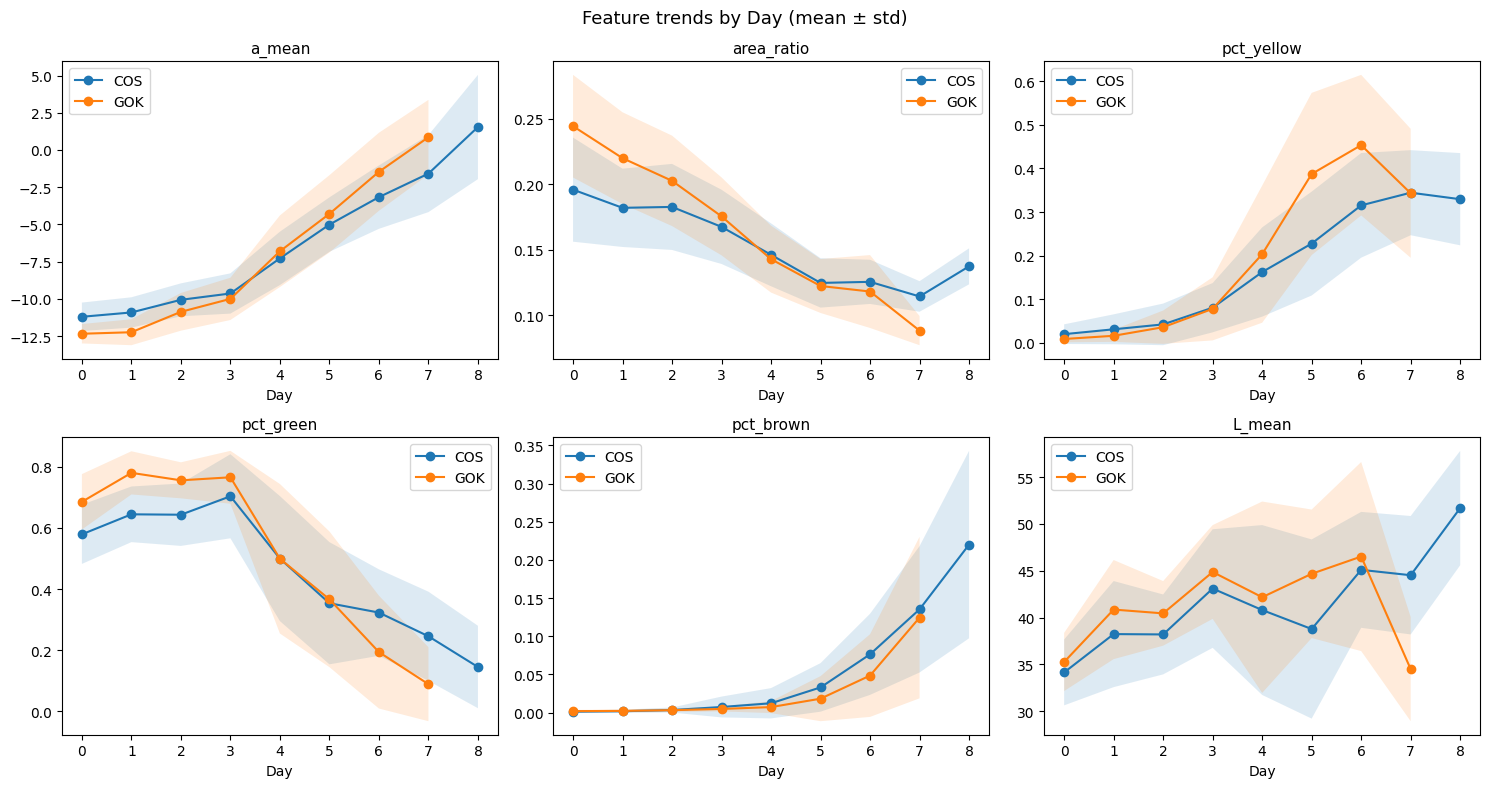

In [2]:
top_feats = ['a_mean', 'area_ratio', 'pct_yellow', 'pct_green', 'pct_brown', 'L_mean']
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, feat in zip(axes.flat, top_feats):
    for var, grp in df.groupby('variety'):
        stats = grp.groupby('day')[feat].agg(['mean','std'])
        ax.plot(stats.index, stats['mean'], marker='o', label=var)
        ax.fill_between(stats.index,
                        stats['mean'] - stats['std'],
                        stats['mean'] + stats['std'], alpha=0.15)
    ax.set_title(feat, fontsize=11)
    ax.set_xlabel('Day')
    ax.legend()
plt.suptitle('Feature trends by Day (mean ± std)', fontsize=13)
plt.tight_layout()
plt.savefig('../results/eda_trends.png', dpi=80, bbox_inches='tight')
plt.show()

## Section 2: Box plot แยก Day

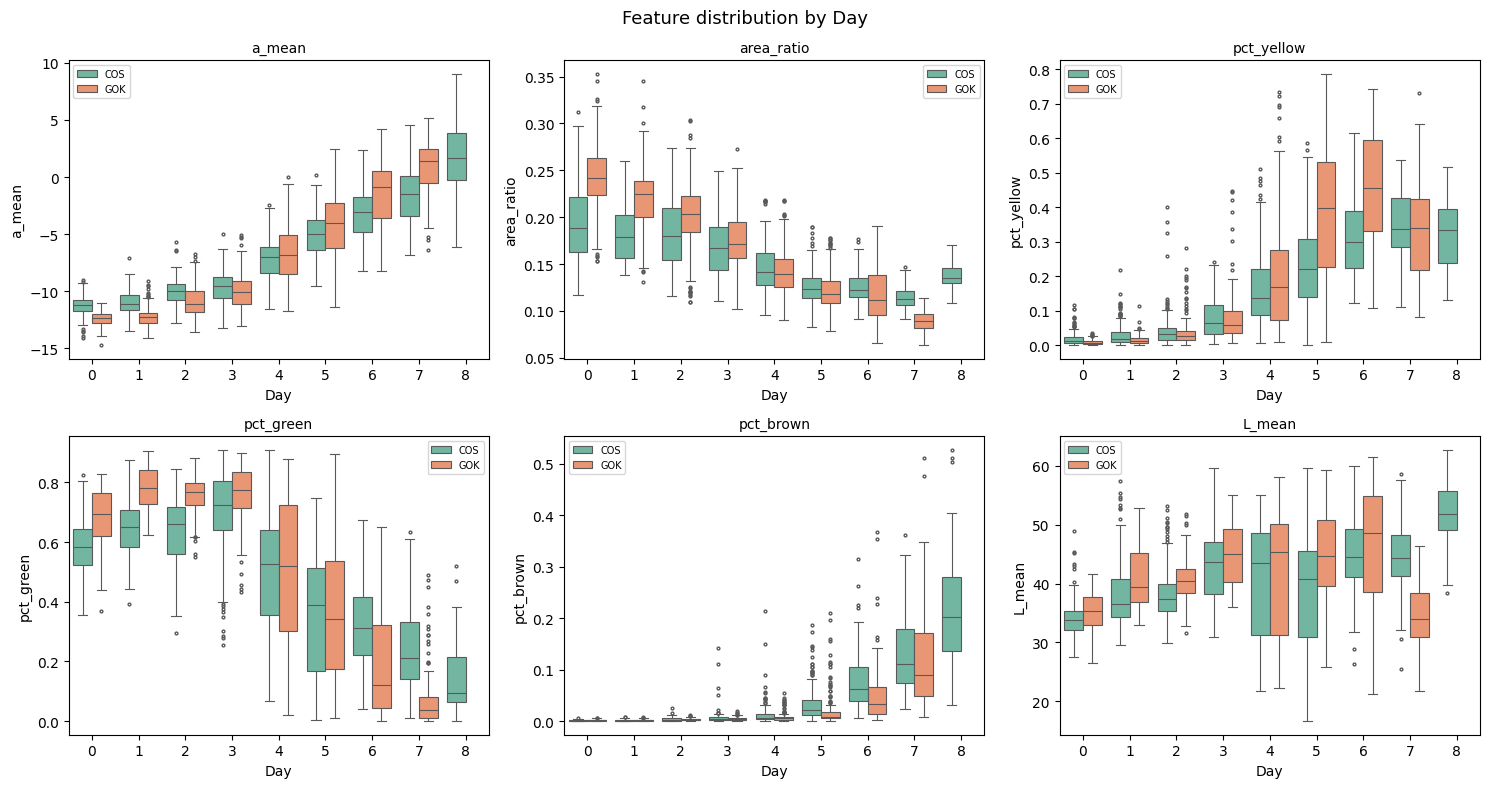

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, feat in zip(axes.flat, top_feats):
    sns.boxplot(data=df, x='day', y=feat, hue='variety', ax=ax,
                palette='Set2', linewidth=0.8, fliersize=2)
    ax.set_title(feat, fontsize=10)
    ax.set_xlabel('Day')
    ax.legend(fontsize=7)
plt.suptitle('Feature distribution by Day', fontsize=13)
plt.tight_layout()
plt.savefig('../results/eda_boxplot.png', dpi=80, bbox_inches='tight')
plt.show()

## Section 3: top vs side view

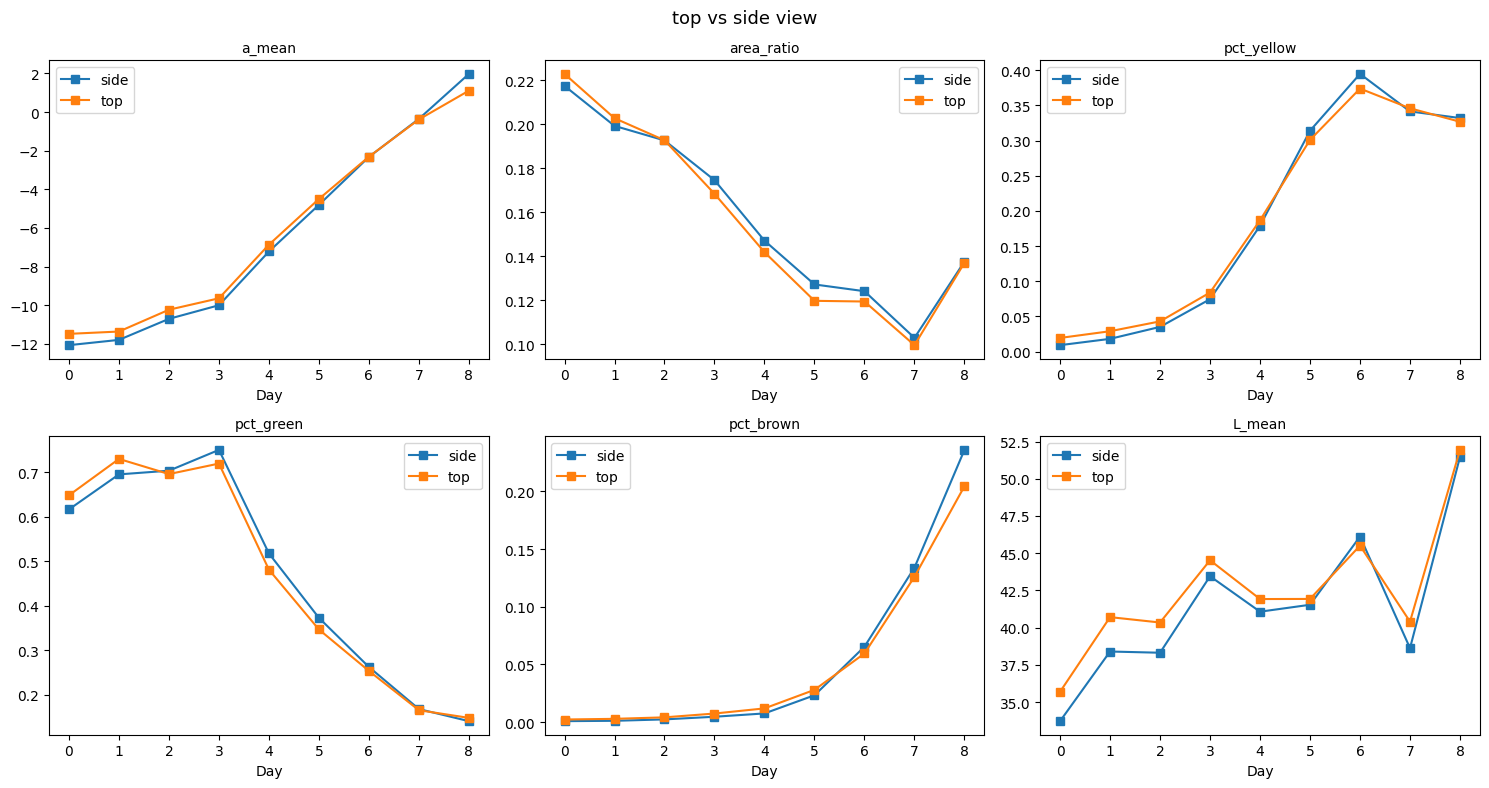

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, feat in zip(axes.flat, top_feats):
    for view, grp in df.groupby('view'):
        means = grp.groupby('day')[feat].mean()
        ax.plot(means.index, means.values, marker='s', label=view)
    ax.set_title(feat, fontsize=10)
    ax.set_xlabel('Day')
    ax.legend()
plt.suptitle('top vs side view', fontsize=13)
plt.tight_layout()
plt.savefig('../results/eda_view_compare.png', dpi=80, bbox_inches='tight')
plt.show()

## Section 4: Outlier detection (IQR)

In [5]:
feat_cols = ['L_mean','a_mean','b_mean','pct_green','pct_yellow','pct_brown','area_ratio']
outlier_rows = pd.Series(False, index=df.index)
for feat in feat_cols:
    q1, q3 = df[feat].quantile(0.25), df[feat].quantile(0.75)
    iqr = q3 - q1
    outlier_rows |= (df[feat] < q1 - 3*iqr) | (df[feat] > q3 + 3*iqr)

print(f'Outlier rows (3x IQR): {outlier_rows.sum()}')
df[outlier_rows][['filename','variety','day','view'] + feat_cols].head(20)

Outlier rows (3x IQR): 336


,filename,variety,day,view,L_mean,a_mean,b_mean,pct_green,pct_yellow,pct_brown,area_ratio
77,COS02_A_D5_E_top.jpg,COS,5,top,49.116516,-3.826195,27.841522,0.325464,0.404984,0.089451,0.101795
78,COS02_A_D5_M_side.jpg,COS,5,side,43.057682,-0.797247,24.810781,0.135672,0.547091,0.105746,0.116123
79,COS02_A_D5_M_top.jpg,COS,5,top,46.571720,-1.696660,23.961363,0.223127,0.461409,0.093806,0.124599
80,COS02_A_D6_E_side.jpg,COS,6,side,42.749809,-4.125583,27.802799,0.368322,0.276630,0.153724,0.105465
81,COS02_A_D6_E_top.jpg,COS,6,top,44.726273,-2.345539,28.053814,0.294727,0.333232,0.192292,0.113136
82,COS02_A_D6_M_side.jpg,COS,6,side,37.119343,-2.906293,22.024645,0.273761,0.304287,0.104496,0.105721
83,COS02_A_D6_M_top.jpg,COS,6,top,37.268822,-1.273578,19.231529,0.130806,0.253672,0.164020,0.102333
84,COS02_A_D7_E_side.jpg,COS,7,side,40.392738,-2.123884,25.603315,0.332774,0.226750,0.231585,0.097828
85,COS02_A_D7_E_top.jpg,COS,7,top,42.655041,0.108253,26.014414,0.241231,0.275310,0.294438,0.099514
86,COS02_A_D7_M_side.jpg,COS,7,side,41.601784,2.876427,22.297089,0.086936,0.293593,0.296982,0.106934


## Section 5: Scatter a_mean vs area_ratio (best 2 features)

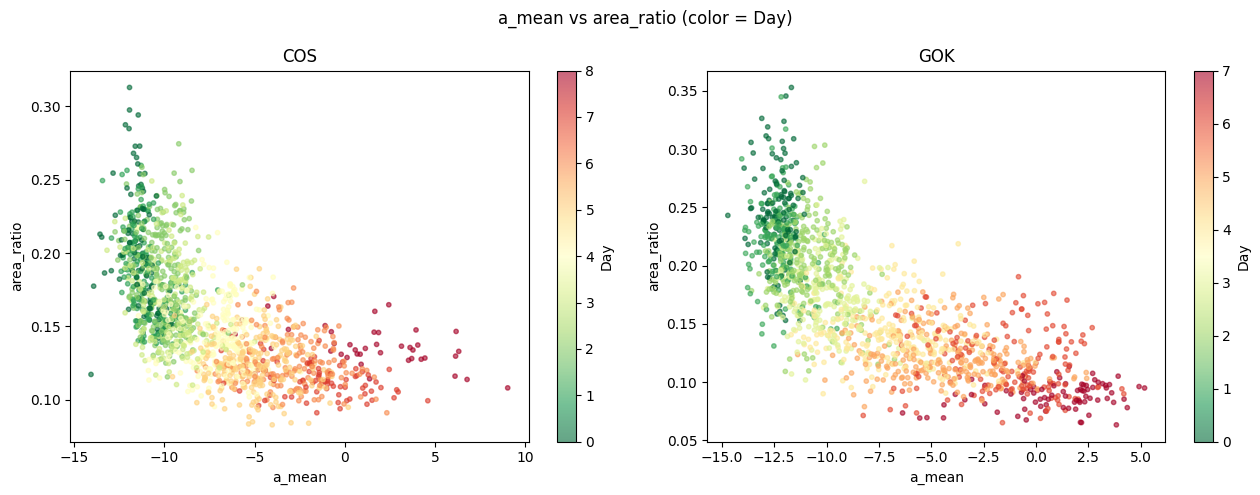

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, var in zip(axes, ['COS', 'GOK']):
    sub = df[df['variety'] == var]
    sc = ax.scatter(sub['a_mean'], sub['area_ratio'],
                    c=sub['day'], cmap='RdYlGn_r', s=10, alpha=0.6)
    plt.colorbar(sc, ax=ax, label='Day')
    ax.set_xlabel('a_mean')
    ax.set_ylabel('area_ratio')
    ax.set_title(var)
plt.suptitle('a_mean vs area_ratio (color = Day)', fontsize=12)
plt.tight_layout()
plt.savefig('../results/eda_scatter.png', dpi=80, bbox_inches='tight')
plt.show()

## Section 6: สรุป EDA

In [7]:
eda_notes = {
    'top_features_confirmed': ['a_mean', 'area_ratio', 'pct_green', 'pct_yellow', 'pct_brown'],
    'view_difference': 'minimal - top/side curves แทบทับกันทุกฟีเจอร์ รวม view ได้ ไม่ต้องแยกโมเดล',
    'variety_difference': 'แนวโน้มทิศทางเดียวกัน แต่ baseline ต่าง: GOK เริ่มเขียวกว่า/area สูงกว่า และ pct_yellow ขึ้นเร็วกว่า COS - ต้องใช้ threshold แยกพันธุ์',
    'outlier_count': int(outlier_rows.sum()),
    'outlier_action': 'flag',
    'notes': 'L_mean ไม่ monotonic พอ (GOK drop ที่ D7, COS noisy ช่วงกลาง) - ใช้เป็น feature เสริมหรือตัดออก | a_mean และ area_ratio แยกวันได้ชัดที่สุดจาก boxplot/scatter | pct_brown เริ่มมีสัญญาณหลัง D4-D5 เท่านั้น - early indicator ไม่ดี | scatter a_mean × area_ratio เห็น day gradient ชัดทั้ง 2 พันธุ์ → ใช้คู่นี้เป็น core features ได้',
}
print(eda_notes)

{'top_features_confirmed': ['a_mean', 'area_ratio', 'pct_green', 'pct_yellow', 'pct_brown'], 'view_difference': 'minimal - top/side curves แทบทับกันทุกฟีเจอร์ รวม view ได้ ไม่ต้องแยกโมเดล', 'variety_difference': 'แนวโน้มทิศทางเดียวกัน แต่ baseline ต่าง: GOK เริ่มเขียวกว่า/area สูงกว่า และ pct_yellow ขึ้นเร็วกว่า COS - ต้องใช้ threshold แยกพันธุ์', 'outlier_count': 336, 'outlier_action': 'flag', 'notes': 'L_mean ไม่ monotonic พอ (GOK drop ที่ D7, COS noisy ช่วงกลาง) - ใช้เป็น feature เสริมหรือตัดออก | a_mean และ area_ratio แยกวันได้ชัดที่สุดจาก boxplot/scatter | pct_brown เริ่มมีสัญญาณหลัง D4-D5 เท่านั้น - early indicator ไม่ดี | scatter a_mean × area_ratio เห็น day gradient ชัดทั้ง 2 พันธุ์ → ใช้คู่นี้เป็น core features ได้'}
